In [2]:
!pip install sqlalchemy
!pip install pymysql

# Import Neccessary Packages

In [3]:
import pandas as pd
import numpy as np
import pymysql
from sklearn.preprocessing import LabelEncoder,scale
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sqlalchemy import create_engine

# Given data

In [4]:
db_host = '18.136.56.185'
username = 'dm_team3'
user_pass = 'dm_team15119#'
db_name = 'project_telecom'

conn = create_engine('mysql+pymysql://'+username+':'+user_pass+'@'+db_host+'/'+db_name)

In [5]:
conn.table_names()

['telecom_churn_data']

# Load The Data

In [6]:
query = 'select * from telecom_churn_data'
telecom_churn_data = pd.read_sql(query,conn)

In [7]:
telecom_churn_data.head()

,columns1,columns2,columns3,columns4,columns5,columns6,columns7,columns8,columns9,columns10,...,columns12,columns13,columns14,columns15,columns16,columns17,columns18,columns19,columns20,columns21
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10,3,2.7,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.7,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.3,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.9,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


In [8]:
telecom_churn_data.columns

Index(['columns1', 'columns2', 'columns3', 'columns4', 'columns5', 'columns6',
       'columns7', 'columns8', 'columns9', 'columns10', 'columns11',
       'columns12', 'columns13', 'columns14', 'columns15', 'columns16',
       'columns17', 'columns18', 'columns19', 'columns20', 'columns21'],
      dtype='object')

In [9]:
telecom_churn_data.shape

(4617, 21)

In [10]:
columns = ['State',
'Account_Length' ,
'Area_Code'  ,
'Phone' ,
'International_Plan', 
'VMail_Plan' ,
'VMail_Message',  
'Day_Mins'  ,
'Day_Calls'  ,
'Day_Charge'  ,
'Eve_Mins'  ,
'Eve_Calls'  ,
'Eve_Charge'  ,
'Night_Mins' ,
'Night_Calls' , 
'Night_Charge' , 
'International_Mins',  
'International_calls',  
'International_Charge',  
'CustServ_Calls',
'Churn']

In [11]:
telecom_churn_data.columns = columns

In [12]:
telecom_churn_data.head()

,State,Account_Length,Area_Code,Phone,International_Plan,VMail_Plan,VMail_Message,Day_Mins,Day_Calls,Day_Charge,...,Eve_Calls,Eve_Charge,Night_Mins,Night_Calls,Night_Charge,International_Mins,International_calls,International_Charge,CustServ_Calls,Churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10,3,2.7,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.7,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.3,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.9,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


# Clean The Data

In [13]:
telecom_churn_data.isnull().sum()

State                   0
Account_Length          0
Area_Code               0
Phone                   0
International_Plan      0
VMail_Plan              0
VMail_Message           0
Day_Mins                0
Day_Calls               0
Day_Charge              0
Eve_Mins                0
Eve_Calls               0
Eve_Charge              0
Night_Mins              0
Night_Calls             0
Night_Charge            0
International_Mins      0
International_calls     0
International_Charge    0
CustServ_Calls          0
Churn                   0
dtype: int64

In [14]:
telecom_churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4617 entries, 0 to 4616
Data columns (total 21 columns):
State                   4617 non-null object
Account_Length          4617 non-null object
Area_Code               4617 non-null object
Phone                   4617 non-null object
International_Plan      4617 non-null object
VMail_Plan              4617 non-null object
VMail_Message           4617 non-null object
Day_Mins                4617 non-null object
Day_Calls               4617 non-null object
Day_Charge              4617 non-null object
Eve_Mins                4617 non-null object
Eve_Calls               4617 non-null object
Eve_Charge              4617 non-null object
Night_Mins              4617 non-null object
Night_Calls             4617 non-null object
Night_Charge            4617 non-null object
International_Mins      4617 non-null object
International_calls     4617 non-null object
International_Charge    4617 non-null object
CustServ_Calls          4617 non-null 

In [15]:
telecom_churn_data.describe()

,State,Account_Length,Area_Code,Phone,International_Plan,VMail_Plan,VMail_Message,Day_Mins,Day_Calls,Day_Charge,...,Eve_Calls,Eve_Charge,Night_Mins,Night_Calls,Night_Charge,International_Mins,International_calls,International_Charge,CustServ_Calls,Churn
count,4617,4617,4617,4617,4617,4617,4617,4617,4617,4617,...,4617,4617,4617,4617,4617,4617,4617,4617,4617,4617
unique,51,218,3,4617,2,2,47,1901,123,1901,...,125,1621,1813,130,1012,168,21,168,10,2
top,WV,90,415,340-6397,no,no,0,154,102,26.18,...,105,14.25,194.3,105,9.66,11.1,3,3,1,False.
freq,149,63,2299,1,4171,3381,3381,10,108,10,...,111,15,10,115,19,81,925,81,1651,3961


In [16]:
telecom_churn_data.drop(labels='Phone',axis=1,inplace=True)

In [17]:
telecom_churn_data.head()

,State,Account_Length,Area_Code,International_Plan,VMail_Plan,VMail_Message,Day_Mins,Day_Calls,Day_Charge,Eve_Mins,Eve_Calls,Eve_Charge,Night_Mins,Night_Calls,Night_Charge,International_Mins,International_calls,International_Charge,CustServ_Calls,Churn
0,KS,128,415,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10,3,2.7,1,False.
1,OH,107,415,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.7,1,False.
2,NJ,137,415,no,no,0,243.4,114,41.38,121.2,110,10.3,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,yes,no,0,299.4,71,50.9,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


# Encoding The Data

In [18]:
enc = LabelEncoder()

In [19]:
X = telecom_churn_data.iloc[:,:-1]
X.Area_Code.value_counts()

415    2299
408    1161
510    1157
Name: Area_Code, dtype: int64

In [20]:
X.State = enc.fit_transform(X.State)
X.International_Plan = enc.fit_transform(X.International_Plan)
X.VMail_Plan = enc.fit_transform(X.VMail_Plan)
X.CustServ_Calls = enc.fit_transform(X.CustServ_Calls)
X.Area_Code = enc.fit_transform(X.Area_Code)

C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\generic.py:5096: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  self[name] = value


In [21]:
X.CustServ_Calls.value_counts()

1    1651
2    1031
0     951
3     616
4     234
5      89
6      28
7      13
9       2
8       2
Name: CustServ_Calls, dtype: int64

In [22]:
X.drop(['VMail_Message','Day_Charge','Eve_Charge','Night_Charge','International_Charge'],axis=1,inplace=True)

C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\frame.py:3940: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  errors=errors)


In [23]:
X.head()

,State,Account_Length,Area_Code,International_Plan,VMail_Plan,Day_Mins,Day_Calls,Eve_Mins,Eve_Calls,Night_Mins,Night_Calls,International_Mins,International_calls,CustServ_Calls
0,16,128,1,0,1,265.1,110,197.4,99,244.7,91,10,3,1
1,35,107,1,0,1,161.6,123,195.5,103,254.4,103,13.7,3,1
2,31,137,1,0,0,243.4,114,121.2,110,162.6,104,12.2,5,0
3,35,84,0,1,0,299.4,71,61.9,88,196.9,89,6.6,7,2
4,36,75,1,1,0,166.7,113,148.3,122,186.9,121,10.1,3,3


In [24]:
X.columns

Index(['State', 'Account_Length', 'Area_Code', 'International_Plan',
       'VMail_Plan', 'Day_Mins', 'Day_Calls', 'Eve_Mins', 'Eve_Calls',
       'Night_Mins', 'Night_Calls', 'International_Mins',
       'International_calls', 'CustServ_Calls'],
      dtype='object')

# Type Casting

In [25]:
X['State'] = X.State.astype('int64')
X['Account_Length'] = X.Account_Length.astype('int64')
X['Day_Mins'] = X.Day_Mins.astype('float64')
X['Day_Calls'] = X.Day_Calls.astype('int64')
X['Eve_Mins'] = X.Eve_Mins.astype('float64')
X['Eve_Calls'] = X.Eve_Calls.astype('int64')
X['Night_Mins'] = X.Night_Mins.astype('float64')
X['Night_Calls'] = X.Night_Calls.astype('int64')
X['International_Mins'] = X.International_Mins.astype('float64')
X['International_calls'] = X.International_calls.astype('int64')

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  """Entry point for launching an IPython kernel.
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.

In [26]:
X.dtypes

State                    int64
Account_Length           int64
Area_Code                int32
International_Plan       int32
VMail_Plan               int32
Day_Mins               float64
Day_Calls                int64
Eve_Mins               float64
Eve_Calls                int64
Night_Mins             float64
Night_Calls              int64
International_Mins     float64
International_calls      int64
CustServ_Calls           int32
dtype: object

In [27]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

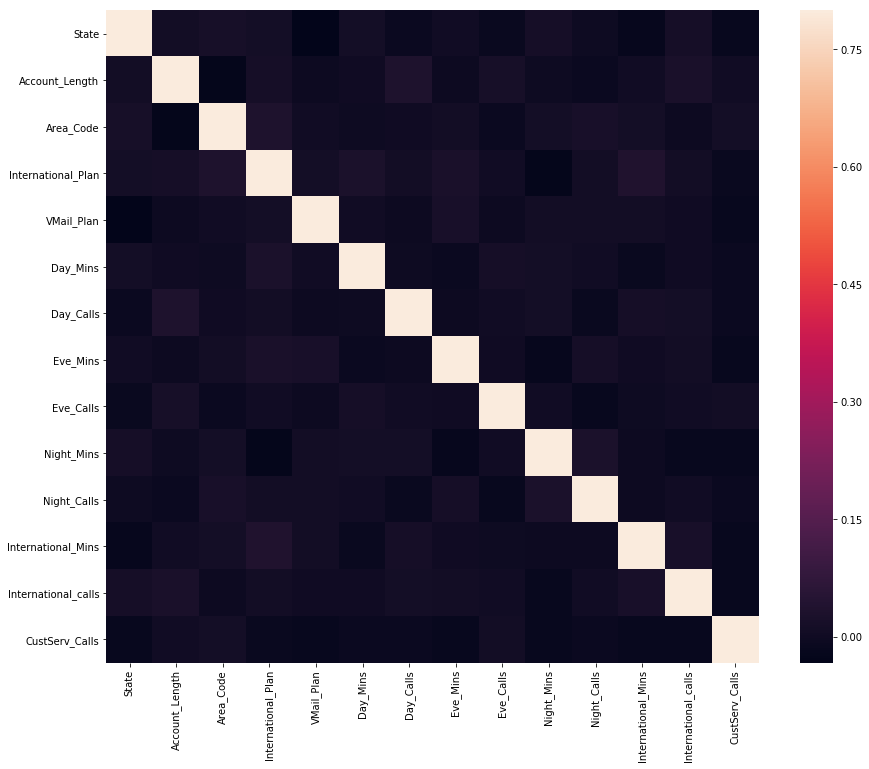

In [28]:
import seaborn as sb
X.corr()

c_mat=X.corr()
f, ax=plt.subplots(figsize=(15,12))
sb.heatmap(c_mat, vmax=0.8, square=True)

In [29]:
#from sklearn.preprocessing import OneHotEncoder
#onehotencoder=OneHotEncoder(categorical_features=[0])
#X=onehotencoder.fit_transform(X).toarray()

In [30]:
X_state=pd.get_dummies(X["State"],drop_first=True)

In [31]:
X_state.head()

,1,2,3,4,5,6,7,8,9,10,...,41,42,43,44,45,46,47,48,49,50
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Model XGBOOST

In [32]:
from xgboost import XGBClassifier

In [33]:
y = telecom_churn_data.Churn

In [34]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=90)

In [35]:
model = XGBClassifier(random_state=90,learning_rate=0.63,n_estimators=149,gamma=0.02,base_score=0.6,n_jobs=1)

In [36]:
model.fit(X_train,y_train)

XGBClassifier(base_score=0.6, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0.02,
              learning_rate=0.63, max_delta_step=0, max_depth=3,
              min_child_weight=1, missing=None, n_estimators=149, n_jobs=1,
              nthread=None, objective='binary:logistic', random_state=90,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
              silent=None, subsample=1, verbosity=1)

In [37]:
y_predict = model.predict(X_test)

In [38]:
accuracy_score(y_test,y_predict)

0.9662337662337662

In [39]:
pd.crosstab(y_test,y_predict)

col_0,False.,True.
Churn,,
False.,991,10
True.,29,125


In [40]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

      False.       0.97      0.99      0.98      1001
       True.       0.93      0.81      0.87       154

    accuracy                           0.97      1155
   macro avg       0.95      0.90      0.92      1155
weighted avg       0.97      0.97      0.97      1155



# Model Random Forest


In [41]:
from sklearn.ensemble import RandomForestClassifier

In [42]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=55)

In [43]:
model = RandomForestClassifier(n_estimators=400,random_state=55,max_depth=20)

In [44]:
model.fit(X_train,y_train)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=20, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=400,
                       n_jobs=None, oob_score=False, random_state=55, verbose=0,
                       warm_start=False)

In [45]:
y_predict = model.predict(X_test)

In [46]:
accuracy_score(y_test,y_predict)

0.9619047619047619

In [47]:
pd.crosstab(y_test,y_predict)

col_0,False.,True.
Churn,,
False.,1002,6
True.,38,109


In [48]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

      False.       0.96      0.99      0.98      1008
       True.       0.95      0.74      0.83       147

    accuracy                           0.96      1155
   macro avg       0.96      0.87      0.91      1155
weighted avg       0.96      0.96      0.96      1155



# SMOTE

In [87]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=9)
X_smote,y_smote = smote.fit_sample(X_train,y_train)

In [88]:
from collections import Counter

In [89]:
print(Counter(y_train))
print(Counter(y_smote))

Counter({' False.': 2960, ' True.': 502})
Counter({' False.': 2960, ' True.': 2960})


In [90]:
from sklearn.ensemble import RandomForestClassifier

In [91]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=90)

In [92]:
model = RandomForestClassifier(n_estimators=600,random_state=90,max_depth=18)

In [93]:
model.fit(X_smote,y_smote)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=18, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=600,
                       n_jobs=None, oob_score=False, random_state=90, verbose=0,
                       warm_start=False)

In [94]:
X_test.shape

(1155, 15)

In [95]:
X_smote.shape

(5920, 14)

In [96]:
y_smote.shape

(5920,)

In [97]:
y_test.shape

(1155,)

In [98]:
X_test.shape

(1155, 15)

In [99]:
y_predict = model.predict(X_test)

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "C:\ProgramData\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py", line 3296, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-99-f3f0823146e6>", line 1, in <module>
    y_predict = model.predict(X_test)
  File "C:\ProgramData\Anaconda3\lib\site-packages\sklearn\ensemble\_forest.py", line 612, in predict
    proba = self.predict_proba(X)
  File "C:\ProgramData\Anaconda3\lib\site-packages\sklearn\ensemble\_forest.py", line 656, in predict_proba
    X = self._validate_X_predict(X)
  File "C:\ProgramData\Anaconda3\lib\site-packages\sklearn\ensemble\_forest.py", line 412, in _validate_X_predict
    return self.estimators_[0]._validate_X_predict(X, check_input=True)
  File "C:\ProgramData\Anaconda3\lib\site-packages\sklearn\tree\_classes.py", line 380, in _validate_X_predict
    X = check_array(X, dtype=DTYPE, accept_sparse="csr")
  File "C:\ProgramData\Anaconda3\lib\site-packages\sklearn\utils\val

ValueError: could not convert string to float: ' False.'

In [ ]:
accuracy_score(y_test,y_predict)

In [ ]:
pd.crosstab(y_test,y_predict)

In [ ]:
print(classification_report(y_test,y_predict))

In [ ]:
from collections import Counter

In [ ]:
from sklearn.ensemble import RandomForestClassifier


In [ ]:
model = RandomForestClassifier(random_state=5,
                               max_depth=15,
                               n_estimators=100)
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model,X,y,cv=5,scoring='accuracy')
print(scores)
print(scores.mean())

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=90)

In [ ]:
model = RandomForestClassifier(n_estimators=600,random_state=90,max_depth=18)

In [ ]:
model.fit(X_train,y_train)

In [ ]:
y_predict = model.predict(X_test)

In [ ]:
accuracy_score(y_test,y_predict)

In [ ]:
pd.crosstab(y_test,y_predict)

In [ ]:
print(classification_report(y_test,y_predict))

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
parameters = {"max_depth":[3,4,6],
             "random_state":range(0,2),
             "n_estimators":[150,170,180,190,200]}
grid = RandomizedSearchCV(model,parameters,cv=5)
grid.fit(X_train,y_train)

In [ ]:
grid.best_score_

In [ ]:
grid.best_estimator_

In [ ]:
grid.best_params_

In [ ]:
y_predict1=grid.predict(X_test)

In [ ]:
accuracy_score(y_test,y_predict1)

In [ ]:
print(classification_report(y_test,y_predict1))

In [ ]:
X['Churn'] =  telecom_churn_data.Churn

In [ ]:
X.corr()

In [100]:
importances = model.feature_importances_
importances

array([0.06000055, 0.05699731, 0.03263704, 0.02149752, 0.0789077 ,
       0.23075645, 0.05033456, 0.09746978, 0.05084828, 0.06873251,
       0.04837254, 0.06586791, 0.05117789, 0.08639996])

In [101]:
import matplotlib.pyplot as plt
import seaborn as sb

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "C:\ProgramData\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py", line 3296, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-102-42c09984a1be>", line 12, in <module>
    plt.barh(range(X_train.shape[1]),importances[indices],align = 'center')
  File "C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\pyplot.py", line 2471, in barh
    y, width, height=height, left=left, align=align, **kwargs)
  File "C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\axes\_axes.py", line 2463, in barh
    align=align, **kwargs)
  File "C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\__init__.py", line 1810, in inner
    return func(ax, *args, **kwargs)
  File "C:\ProgramData\Anaconda3\lib\site-packages\matplotlib\axes\_axes.py", line 2251, in bar
    np.atleast_1d(x), height, width, y, linewidth)
  File "C:\ProgramData\Anaconda3\lib\site-packages\numpy\lib\stride_tricks.py", line 259, in broadcast

ValueError: shape mismatch: objects cannot be broadcast to a single shape

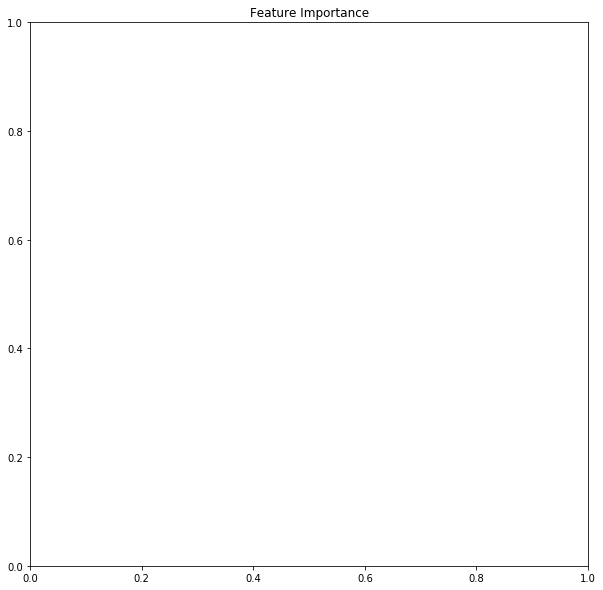

In [102]:
# Sort feature importances in descending order
indices = np.argsort(importances)[::1]

# Rearrange feature names so they match the sorted feature importances
names = [X_train.columns[i] for i in indices]

# Creating plot
fig = plt.figure(figsize=(10,10))
plt.title("Feature Importance")

# Add horizontal bars
plt.barh(range(X_train.shape[1]),importances[indices],align = 'center')
plt.yticks(range(X_train.shape[1]), names,percentage)
plt.show()
#fig.savefig('feature_importance.png')

In [ ]:
from sklearn.metrics import roc_curve,auc,roc_auc_score

In [103]:
y_predict = enc.fit_transform(y_predict)

In [104]:
y_test = enc.fit_transform(y_test)

In [105]:
X.drop(labels='Churn',axis=1,inplace=True)

C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\frame.py:3940: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  errors=errors)


In [106]:
Risk_score = model.predict_proba(X)

In [107]:
Prob_1,Prob_2 = np.hsplit(Risk_score,2)

In [108]:
telecom_churn_data['Churn_risk_score'] = Prob_1

In [109]:
telecom_churn_data['1-Riskscore'] = Prob_2

In [110]:
telecom_churn_data.Churn = enc.fit_transform(telecom_churn_data.Churn)

In [111]:
telecom_churn_data['CHURN-FLAG'] = telecom_churn_data.Churn

In [112]:
telecom_churn_data.drop(labels='Churn',axis=1,inplace=True)

In [113]:
telecom_churn_data.head(20)

,State,Account_Length,Area_Code,International_Plan,VMail_Plan,VMail_Message,Day_Mins,Day_Calls,Day_Charge,Eve_Mins,...,Night_Mins,Night_Calls,Night_Charge,International_Mins,International_calls,International_Charge,CustServ_Calls,Churn_risk_score,1-Riskscore,CHURN-FLAG
0,KS,128,415,no,yes,25,265.1,110,45.07,197.4,...,244.7,91,11.01,10,3,2.7,1,0.968704,0.031296,0
1,OH,107,415,no,yes,26,161.6,123,27.47,195.5,...,254.4,103,11.45,13.7,3,3.7,1,0.949641,0.050359,0
2,NJ,137,415,no,no,0,243.4,114,41.38,121.2,...,162.6,104,7.32,12.2,5,3.29,0,0.875830,0.124170,0
3,OH,84,408,yes,no,0,299.4,71,50.9,61.9,...,196.9,89,8.86,6.6,7,1.78,2,0.808667,0.191333,0
4,OK,75,415,yes,no,0,166.7,113,28.34,148.3,...,186.9,121,8.41,10.1,3,2.73,3,0.784033,0.215967,0
5,AL,118,510,yes,no,0,223.4,98,37.98,220.6,...,203.9,118,9.18,6.3,6,1.7,0,0.875556,0.124444,0
6,MA,121,510,no,yes,24,218.2,88,37.09,348.5,...,212.6,118,9.57,7.5,7,2.03,3,0.900263,0.099737,0
7,MO,147,415,yes,no,0,157,79,26.69,103.1,...,211.8,96,9.53,7.1,6,1.92,0,0.939737,0.060263,0
8,LA,117,408,no,no,0,184.5,97,31.37,351.6,...,215.8,90,9.71,8.7,4,2.35,1,0.790441,0.209559,0
9,WV,141,415,yes,yes,37,258.6,84,43.96,222,...,326.4,97,14.69,11.2,5,3.02,0,0.893333,0.106667,0


In [114]:
telecom_churn_data.to_csv('Churn-Predicted-Result.csv')

In [115]:
telecom_churn_data


,State,Account_Length,Area_Code,International_Plan,VMail_Plan,VMail_Message,Day_Mins,Day_Calls,Day_Charge,Eve_Mins,...,Night_Mins,Night_Calls,Night_Charge,International_Mins,International_calls,International_Charge,CustServ_Calls,Churn_risk_score,1-Riskscore,CHURN-FLAG
0,KS,128,415,no,yes,25,265.1,110,45.07,197.4,...,244.7,91,11.01,10,3,2.7,1,0.968704,0.031296,0
1,OH,107,415,no,yes,26,161.6,123,27.47,195.5,...,254.4,103,11.45,13.7,3,3.7,1,0.949641,0.050359,0
2,NJ,137,415,no,no,0,243.4,114,41.38,121.2,...,162.6,104,7.32,12.2,5,3.29,0,0.875830,0.124170,0
3,OH,84,408,yes,no,0,299.4,71,50.9,61.9,...,196.9,89,8.86,6.6,7,1.78,2,0.808667,0.191333,0
4,OK,75,415,yes,no,0,166.7,113,28.34,148.3,...,186.9,121,8.41,10.1,3,2.73,3,0.784033,0.215967,0
5,AL,118,510,yes,no,0,223.4,98,37.98,220.6,...,203.9,118,9.18,6.3,6,1.7,0,0.875556,0.124444,0
6,MA,121,510,no,yes,24,218.2,88,37.09,348.5,...,212.6,118,9.57,7.5,7,2.03,3,0.900263,0.099737,0
7,MO,147,415,yes,no,0,157,79,26.69,103.1,...,211.8,96,9.53,7.1,6,1.92,0,0.939737,0.060263,0
8,LA,117,408,no,no,0,184.5,97,31.37,351.6,...,215.8,90,9.71,8.7,4,2.35,1,0.790441,0.209559,0
9,WV,141,415,yes,yes,37,258.6,84,43.96,222,...,326.4,97,14.69,11.2,5,3.02,0,0.893333,0.106667,0
